# PTB-XL Train / PTBDB Test for Binary MI Classification

This notebook preprocesses both datasets with the same beat-extraction pipeline used in the original notebook, saves the processed beats into separate subfolders, trains two baseline models on PTB-XL, and evaluates subject-level performance on PTBDB.


## 1. Imports and Paths

The notebook expects `wfdb`, `biosppy`, `torch`, `pywavelets`, `numpy`, `pandas`, and `scikit-learn` to be installed in the active kernel.


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

from pathlib import Path, PureWindowsPath
import shutil
import pandas as pd

DRIVE_ROOT = Path("/content/drive/MyDrive/FinalProject")
DRIVE_PTBXL = DRIVE_ROOT / "data/processed_beats/ptbxl"
DRIVE_PTBDB = DRIVE_ROOT / "data/processed_beats/ptbdb"

LOCAL_ROOT = Path("/content/556final_project_data")
LOCAL_PTBXL = LOCAL_ROOT / "ptbxl"
LOCAL_PTBDB = LOCAL_ROOT / "ptbdb"
# LOCAL_ROOT.mkdir(parents=True, exist_ok=True)
# LOCAL_PTBXL.mkdir(parents=True, exist_ok=True)
# LOCAL_PTBDB.mkdir(parents=True, exist_ok=True)

# shutil.copy(DRIVE_PTBXL / "metadata.csv", LOCAL_PTBXL / "metadata.csv")
# shutil.copy(DRIVE_PTBDB / "metadata.csv", LOCAL_PTBDB / "metadata.csv")

if LOCAL_PTBXL.exists():
    shutil.rmtree(LOCAL_PTBXL)
if LOCAL_PTBDB.exists():
    shutil.rmtree(LOCAL_PTBDB)

In [ ]:
!cp -r "$DRIVE_PTBXL" "$LOCAL_PTBXL"
!cp -r "$DRIVE_PTBDB" "$LOCAL_PTBDB"

In [ ]:
import shutil
ptbxl_metadata = pd.read_csv(LOCAL_PTBXL / "metadata.csv")
ptbdb_metadata = pd.read_csv(LOCAL_PTBDB / "metadata.csv")

ptbxl_metadata["file_path"] = ptbxl_metadata["file_path"].apply(
    lambda p: str(LOCAL_PTBXL / PureWindowsPath(p).name)
)
ptbdb_metadata["file_path"] = ptbdb_metadata["file_path"].apply(
    lambda p: str(LOCAL_PTBDB / PureWindowsPath(p).name)
)

ptbxl_metadata.to_csv(LOCAL_PTBXL / "metadata_local.csv", index=False)
ptbdb_metadata.to_csv(LOCAL_PTBDB / "metadata_local.csv", index=False)

In [ ]:
!pip install wfdb biosppy pywavelets scikit-learn

In [ ]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import sys

PROJECT_ROOT = Path('/content/drive/MyDrive/FinalProject')
sys.path.insert(0, str(PROJECT_ROOT))
print(PROJECT_ROOT)
print((PROJECT_ROOT / 'util').exists())


from util.ecg_pipeline import (
    build_dataloaders,
    build_test_loader,
    preprocess_ptbdb_dataset,
    preprocess_ptbxl_dataset,
    summarize_metadata,
)
from util.models import CNN_LSTM, ECG_CNN_Transformer, FocalLoss
from util.models import CNN_LTC, CNN_CTRNN, CNN_NeuralODE, CNN_CTGRU
from util.training import evaluate_subjects, find_best_subject_cutoff, train_model


ARTIFACT_ROOT = PROJECT_ROOT / 'artifacts'
CHECKPOINT_ROOT = ARTIFACT_ROOT / 'checkpoints'
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE


/content/drive/MyDrive/FinalProject
True


'cuda'

## 3. Build Loaders

PTB-XL is used for training and validation. PTBDB is held out for final subject-level testing.


In [ ]:
BATCH_SIZE = 128
VAL_SIZE = 0.2

# ptbxl_metadata_path = DRIVE_PTBXL / 'metadata_fixed.csv'
# ptbdb_metadata_path = DRIVE_PTBDB / 'metadata_fixed.csv'
ptbxl_metadata_path = LOCAL_PTBXL / "metadata_local.csv"
ptbdb_metadata_path = LOCAL_PTBDB / "metadata_local.csv"

train_loader_cnn, val_loader_cnn, train_meta_cnn, val_meta_cnn = build_dataloaders(
    train_metadata_path=ptbxl_metadata_path,
    batch_size=BATCH_SIZE,
    val_size=VAL_SIZE,
    use_dwt=False,
    num_workers=0,
)
test_loader_cnn, test_meta_cnn = build_test_loader(
    metadata_path=ptbdb_metadata_path,
    batch_size=BATCH_SIZE,
    use_dwt=False,
    num_workers=0,
)

train_loader_transformer, val_loader_transformer, _, _ = build_dataloaders(
    train_metadata_path=ptbxl_metadata_path,
    batch_size=BATCH_SIZE,
    val_size=VAL_SIZE,
    use_dwt=True,
    num_workers=0,
)
test_loader_transformer, _ = build_test_loader(
    metadata_path=ptbdb_metadata_path,
    batch_size=BATCH_SIZE,
    use_dwt=True,
    num_workers=0,
)

print('CNN train beats:', len(train_meta_cnn), 'val beats:', len(val_meta_cnn), 'test beats:', len(test_meta_cnn))


CNN train beats: 11539 val beats: 2893 test beats: 4862


In [ ]:
counts = val_meta_cnn['label_name'].value_counts()
print(counts)

label_name
control    1789
patient    1104
Name: count, dtype: int64


In [ ]:
unique_subjects = train_meta_cnn.drop_duplicates(subset='subject_id')
counts = unique_subjects['label_name'].value_counts()
print(counts)

label_name
control    6694
patient    3744
Name: count, dtype: int64


In [ ]:
unique_subjects = val_meta_cnn.drop_duplicates(subset='subject_id')
counts = unique_subjects['label_name'].value_counts()
print(counts)

label_name
control    1674
patient     936
Name: count, dtype: int64


In [ ]:
print(train_meta_cnn['label'].value_counts())
print(val_meta_cnn['label'].value_counts())
print(test_meta_cnn['label'].value_counts())

label
0    7157
1    4382
Name: count, dtype: int64
label
0    1789
1    1104
Name: count, dtype: int64
label
1    3934
0     928
Name: count, dtype: int64


In [ ]:
def pick_window_size(seq_len: int) -> int:
    pooled_len = seq_len // 4
    preferred = [13, 12, 10, 8, 6, 5, 4, 3, 2, 1]
    for candidate in preferred:
        if pooled_len % candidate == 0:
            return candidate
    raise ValueError(f'No valid window size found for seq_len={seq_len}')

cnn_input_shape = next(iter(train_loader_cnn))[0].shape
transformer_input_shape = next(iter(train_loader_transformer))[0].shape
print('CNN input shape:', cnn_input_shape)
print('Transformer input shape:', transformer_input_shape)

CNN input shape: torch.Size([128, 1, 150])
Transformer input shape: torch.Size([128, 1, 156])


## 4. Helper for Reporting


In [ ]:
def print_subject_metrics(name: str, metrics: dict):
    print(name)
    print(f"  cutoff:      {metrics['cutoff']:.2f}")
    print(f"  accuracy:    {metrics['accuracy']:.4f}")
    print(f"  f1:          {metrics['f1']:.4f}")
    print(f"  sensitivity: {metrics['sensitivity']:.4f}")
    print(f"  specificity: {metrics['specificity']:.4f}")
    print(f"  roc_auc:     {metrics['roc_auc']:.4f}")


## 5. Baseline 1: CNN-LSTM


In [ ]:
cnn_lstm = CNN_LSTM(n_classes=1).to(DEVICE)
criterion = FocalLoss(alpha=0.5, gamma=2.0)
optimizer = torch.optim.Adam(cnn_lstm.parameters(), lr=1e-3, weight_decay=1e-4)

cnn_lstm, cnn_history = train_model(
    model=cnn_lstm,
    train_loader=train_loader_cnn,
    val_loader=val_loader_cnn,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    epochs=100,
    checkpoint_path=CHECKPOINT_ROOT / "cnn_lstm_ptbxl_to_ptbdb.pt",
    verbose=True,
    show_epoch_progress=True,
    show_batch_progress=False,
)


cnn_cutoff, cnn_val_subject_metrics = find_best_subject_cutoff(
    model=cnn_lstm,
    loader=val_loader_cnn,
    criterion=criterion,
    device=DEVICE,
)
cnn_test_subject_metrics = evaluate_subjects(
    model=cnn_lstm,
    loader=test_loader_cnn,
    criterion=criterion,
    device=DEVICE,
    cutoff=cnn_cutoff,
)

print_subject_metrics('CNN-LSTM validation subjects', cnn_val_subject_metrics)
print_subject_metrics('CNN-LSTM PTBDB test subjects', cnn_test_subject_metrics)


Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

Epoch 1/100 | train_loss=0.0712 | val_loss=0.0568 | val_acc=0.8161 | val_f1=0.7936 | val_sens=0.6368 | val_spec=0.9268 | val_auc=0.8697
Epoch 2/100 | train_loss=0.0537 | val_loss=0.0513 | val_acc=0.8310 | val_f1=0.8209 | val_sens=0.7781 | val_spec=0.8636 | val_auc=0.8972
Epoch 3/100 | train_loss=0.0495 | val_loss=0.0557 | val_acc=0.8213 | val_f1=0.7910 | val_sens=0.5770 | val_spec=0.9721 | val_auc=0.8934
Epoch 4/100 | train_loss=0.0489 | val_loss=0.0473 | val_acc=0.8527 | val_f1=0.8361 | val_sens=0.7002 | val_spec=0.9469 | val_auc=0.9062
Epoch 5/100 | train_loss=0.0475 | val_loss=0.0468 | val_acc=0.8493 | val_f1=0.8370 | val_sens=0.7536 | val_spec=0.9083 | val_auc=0.9084
Epoch 6/100 | train_loss=0.0463 | val_loss=0.0506 | val_acc=0.8382 | val_f1=0.8305 | val_sens=0.8179 | val_spec=0.8508 | val_auc=0.9081
Epoch 7/100 | train_loss=0.0468 | val_loss=0.0471 | val_acc=0.8559 | val_f1=0.8410 | val_sens=0.7210 | val_spec=0.9391 | val_auc=0.9057
Epoch 8/100 | train_loss=0.0453 | val_loss=0.047

In [ ]:
cnn_lstm = CNN_LSTM(n_classes=1).to(DEVICE)
checkpoint = torch.load(CHECKPOINT_ROOT / "cnn_lstm_ptbxl_to_ptbdb.pt", map_location=DEVICE)

cnn_lstm.load_state_dict(checkpoint)
cnn_lstm.eval()

CNN_LSTM(
  (conv_blocks): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv1d(128, 64, kernel_size=(3,), stride=(1,))
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): MaxPool1d(kernel_size=2, stride=2, padding=0, dilati

In [ ]:
criterion = FocalLoss(alpha=0.5, gamma=2.0)
cnn_cutoff, cnn_val_subject_metrics = find_best_subject_cutoff(
    model=cnn_lstm,
    loader=val_loader_cnn,
    criterion=criterion,
    device=DEVICE,
)
cnn_test_subject_metrics = evaluate_subjects(
    model=cnn_lstm,
    loader=test_loader_cnn,
    criterion=criterion,
    device=DEVICE,
    cutoff=cnn_cutoff,
)
print_subject_metrics('CNN-LSTM validation subjects', cnn_val_subject_metrics)
print_subject_metrics('CNN-LSTM PTBDB test subjects', cnn_test_subject_metrics)

CNN-LSTM validation subjects
  cutoff:      0.10
  accuracy:    0.8613
  f1:          0.8431
  sensitivity: 0.7254
  specificity: 0.9373
  roc_auc:     0.8320
CNN-LSTM PTBDB test subjects
  cutoff:      0.10
  accuracy:    0.8500
  f1:          0.8277
  sensitivity: 0.8176
  specificity: 0.9423
  roc_auc:     0.8902


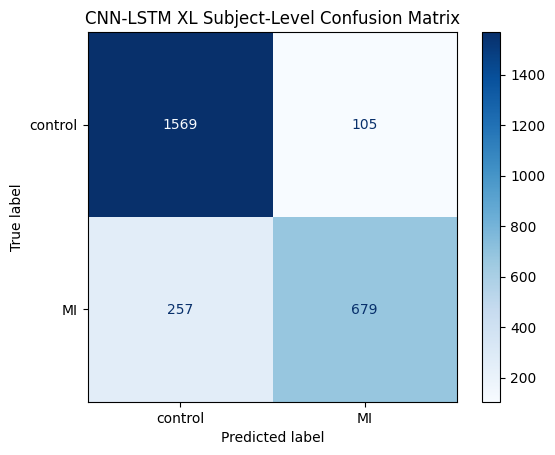

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = cnn_val_subject_metrics["confusion_matrix"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["control", "MI"])
disp.plot(cmap="Blues", values_format="d")
plt.title("CNN-LSTM XL Subject-Level Confusion Matrix")
plt.show()

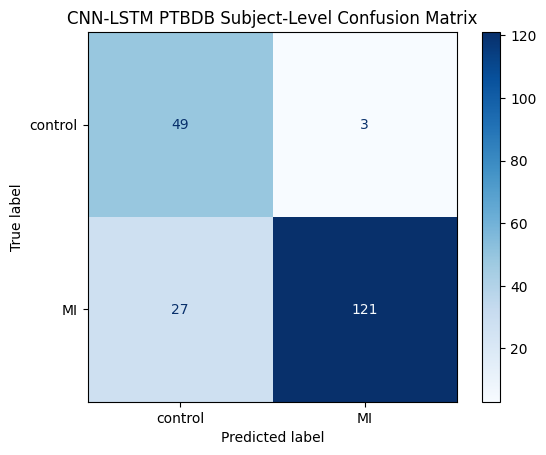

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = cnn_test_subject_metrics["confusion_matrix"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["control", "MI"])
disp.plot(cmap="Blues", values_format="d")
plt.title("CNN-LSTM PTBDB Subject-Level Confusion Matrix")
plt.show()

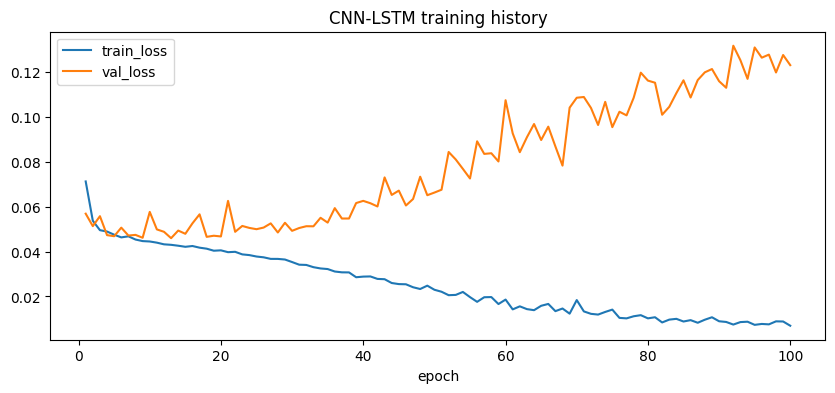

In [ ]:
cnn_history_df = pd.DataFrame(cnn_history)
plt.figure(figsize=(10, 4))
plt.plot(cnn_history_df['epoch'], cnn_history_df['train_loss'], label='train_loss')
plt.plot(cnn_history_df['epoch'], cnn_history_df['val_loss'], label='val_loss')
# plt.plot(cnn_history_df['epoch'], cnn_history_df['val_f1'], label='val_f1')
plt.title('CNN-LSTM training history')
plt.xlabel('epoch')
plt.legend()
plt.show()


## 6. Baseline 2: CNN-Transformer on DWT Beats


In [ ]:
transformer_seq_len = int(transformer_input_shape[-1])
transformer_window = pick_window_size(transformer_seq_len)

cnn_transformer = ECG_CNN_Transformer(
    seq_len=transformer_seq_len,
    window_size=transformer_window,
).to(DEVICE)
criterion = FocalLoss(alpha=0.5, gamma=2.0)
optimizer = torch.optim.AdamW(cnn_transformer.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
)

cnn_transformer, transformer_history = train_model(
    model=cnn_transformer,
    train_loader=train_loader_transformer,
    val_loader=val_loader_transformer,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=DEVICE,
    epochs=100,
    checkpoint_path=CHECKPOINT_ROOT / 'cnn_transformer_ptbxl_to_ptbdb.pt',
    verbose=True,
    show_epoch_progress=True,
    show_batch_progress=False,
)


transformer_cutoff, transformer_val_subject_metrics = find_best_subject_cutoff(
    model=cnn_transformer,
    loader=val_loader_transformer,
    criterion=criterion,
    device=DEVICE,
)
transformer_test_subject_metrics = evaluate_subjects(
    model=cnn_transformer,
    loader=test_loader_transformer,
    criterion=criterion,
    device=DEVICE,
    cutoff=transformer_cutoff,
)

print_subject_metrics('CNN-Transformer validation subjects', transformer_val_subject_metrics)
print_subject_metrics('CNN-Transformer PTBDB test subjects', transformer_test_subject_metrics)


Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

Epoch 1/100 | train_loss=0.0743 | val_loss=0.0663 | val_acc=0.7611 | val_f1=0.7255 | val_sens=0.5254 | val_spec=0.9067 | val_auc=0.8091
Epoch 2/100 | train_loss=0.0644 | val_loss=0.0582 | val_acc=0.8019 | val_f1=0.7786 | val_sens=0.6250 | val_spec=0.9111 | val_auc=0.8539
Epoch 3/100 | train_loss=0.0594 | val_loss=0.0576 | val_acc=0.8075 | val_f1=0.7936 | val_sens=0.7183 | val_spec=0.8625 | val_auc=0.8680
Epoch 4/100 | train_loss=0.0573 | val_loss=0.0546 | val_acc=0.8241 | val_f1=0.8053 | val_sens=0.6730 | val_spec=0.9173 | val_auc=0.8716
Epoch 5/100 | train_loss=0.0552 | val_loss=0.0531 | val_acc=0.8258 | val_f1=0.8059 | val_sens=0.6630 | val_spec=0.9262 | val_auc=0.8838
Epoch 6/100 | train_loss=0.0531 | val_loss=0.0520 | val_acc=0.8337 | val_f1=0.8118 | val_sens=0.6449 | val_spec=0.9503 | val_auc=0.8881
Epoch 7/100 | train_loss=0.0518 | val_loss=0.0516 | val_acc=0.8258 | val_f1=0.8024 | val_sens=0.6313 | val_spec=0.9458 | val_auc=0.8906
Epoch 8/100 | train_loss=0.0502 | val_loss=0.051

In [ ]:
transformer_seq_len = int(transformer_input_shape[-1])
transformer_window = pick_window_size(transformer_seq_len)

cnn_transformer = ECG_CNN_Transformer(
    seq_len=transformer_seq_len,
    window_size=transformer_window,
).to(DEVICE)
criterion = FocalLoss(alpha=0.5, gamma=2.0)
optimizer = torch.optim.AdamW(cnn_transformer.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
)


checkpoint = torch.load(CHECKPOINT_ROOT / "cnn_transformer_ptbxl_to_ptbdb.pt", map_location=DEVICE)

cnn_transformer.load_state_dict(checkpoint)
cnn_transformer.eval()


ECG_CNN_Transformer(
  (cnn): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (embedding): Linear(in_features=832, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLine

In [ ]:
criterion = FocalLoss(alpha=0.5, gamma=2.0)
transformer_cutoff, transformer_val_subject_metrics = find_best_subject_cutoff(
    model=cnn_transformer,
    loader=val_loader_transformer,
    criterion=criterion,
    device=DEVICE,
)
transformer_test_subject_metrics = evaluate_subjects(
    model=cnn_transformer,
    loader=test_loader_transformer,
    criterion=criterion,
    device=DEVICE,
    cutoff=transformer_cutoff,
)

print_subject_metrics('CNN-Transformer validation subjects', transformer_val_subject_metrics)
print_subject_metrics('CNN-Transformer PTBDB test subjects', transformer_test_subject_metrics)

CNN-Transformer validation subjects
  cutoff:      0.10
  accuracy:    0.8444
  f1:          0.8261
  sensitivity: 0.7244
  specificity: 0.9116
  roc_auc:     0.8194
CNN-Transformer PTBDB test subjects
  cutoff:      0.10
  accuracy:    0.8300
  f1:          0.8047
  sensitivity: 0.8041
  specificity: 0.9038
  roc_auc:     0.9127


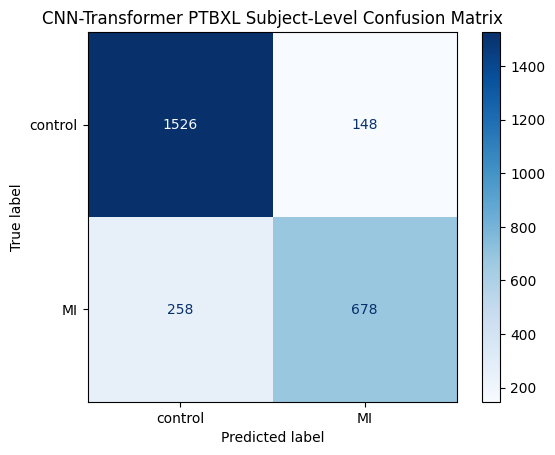

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = transformer_val_subject_metrics["confusion_matrix"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["control", "MI"])
disp.plot(cmap="Blues", values_format="d")
plt.title("CNN-Transformer PTBXL Subject-Level Confusion Matrix")
plt.show()

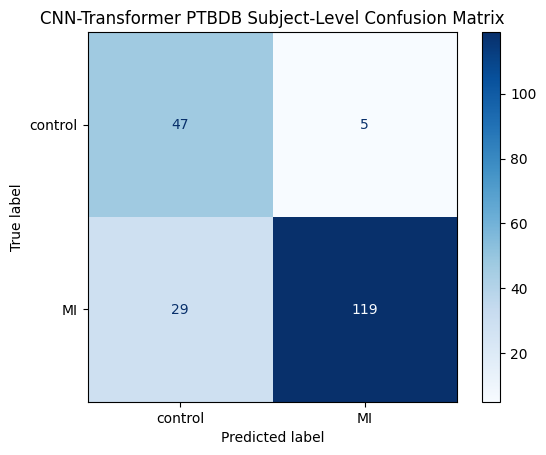

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = transformer_test_subject_metrics["confusion_matrix"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["control", "MI"])
disp.plot(cmap="Blues", values_format="d")
plt.title("CNN-Transformer PTBDB Subject-Level Confusion Matrix")
plt.show()

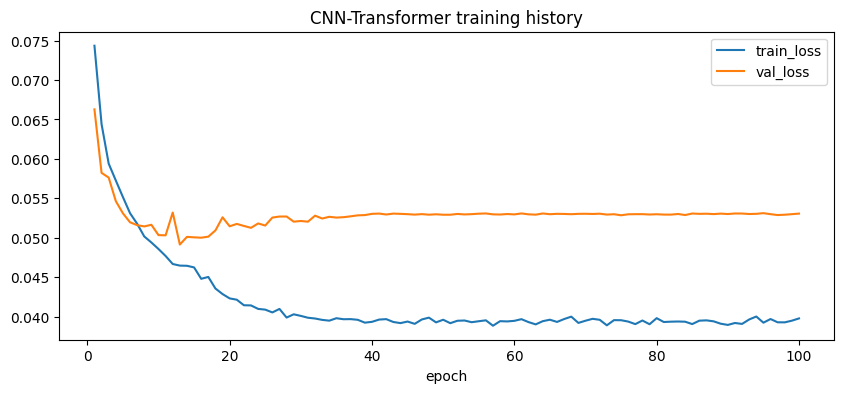

In [ ]:
transformer_history_df = pd.DataFrame(transformer_history)
plt.figure(figsize=(10, 4))
plt.plot(transformer_history_df['epoch'], transformer_history_df['train_loss'], label='train_loss')
plt.plot(transformer_history_df['epoch'], transformer_history_df['val_loss'], label='val_loss')
# plt.plot(transformer_history_df['epoch'], transformer_history_df['val_f1'], label='val_f1')
plt.title('CNN-Transformer training history')
plt.xlabel('epoch')
plt.legend()
plt.show()


Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50 | train_loss=0.0620 | val_loss=0.0542 | val_acc=0.6301 | val_f1=0.4163 | val_sens=0.0326 | val_spec=0.9989 | val_auc=0.8493
Epoch 2/50 | train_loss=0.0498 | val_loss=0.0494 | val_acc=0.7418 | val_f1=0.6652 | val_sens=0.3451 | val_spec=0.9866 | val_auc=0.8700
Epoch 3/50 | train_loss=0.0457 | val_loss=0.0464 | val_acc=0.7487 | val_f1=0.6761 | val_sens=0.3605 | val_spec=0.9883 | val_auc=0.8813
Epoch 4/50 | train_loss=0.0431 | val_loss=0.0463 | val_acc=0.8258 | val_f1=0.8001 | val_sens=0.6123 | val_spec=0.9575 | val_auc=0.8908
Epoch 5/50 | train_loss=0.0411 | val_loss=0.0429 | val_acc=0.8075 | val_f1=0.7709 | val_sens=0.5344 | val_spec=0.9760 | val_auc=0.8974
Epoch 6/50 | train_loss=0.0399 | val_loss=0.0404 | val_acc=0.8092 | val_f1=0.7720 | val_sens=0.5308 | val_spec=0.9810 | val_auc=0.9016
Epoch 7/50 | train_loss=0.0386 | val_loss=0.0431 | val_acc=0.7580 | val_f1=0.6893 | val_sens=0.3768 | val_spec=0.9933 | val_auc=0.8991
Epoch 8/50 | train_loss=0.0382 | val_loss=0.0394 | val_

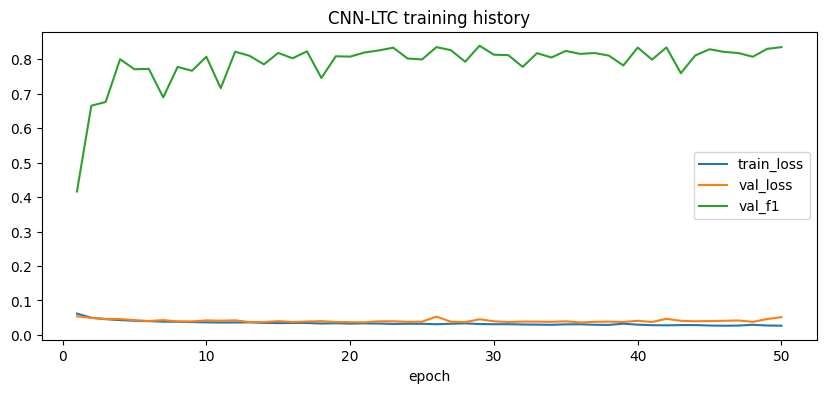

In [ ]:
ltc_model = CNN_LTC(n_classes=1).to(DEVICE)
criterion_ct = FocalLoss(alpha=0.25, gamma=2.0)
optimizer_ltc = torch.optim.Adam(ltc_model.parameters(), lr=1e-3, weight_decay=1e-4)

ltc_model, ltc_history = train_model(
    model=ltc_model,
    train_loader=train_loader_cnn,
    val_loader=val_loader_cnn,
    criterion=criterion_ct,
    optimizer=optimizer_ltc,
    device=DEVICE,
    epochs=50,
    checkpoint_path=CHECKPOINT_ROOT / 'cnn_ltc_ptbxl_to_ptbdb.pt',
)

ltc_cutoff, ltc_val_metrics = find_best_subject_cutoff(ltc_model, val_loader_cnn, criterion_ct, DEVICE)
ltc_test_metrics = evaluate_subjects(ltc_model, test_loader_cnn, criterion_ct, DEVICE, cutoff=ltc_cutoff)

print_subject_metrics('CNN-LTC validation subjects', ltc_val_metrics)
print_subject_metrics('CNN-LTC PTBDB test subjects', ltc_test_metrics)

ltc_history_df = pd.DataFrame(ltc_history)
ltc_history_df.tail()

plt.figure(figsize=(10, 4))
plt.plot(ltc_history_df['epoch'], ltc_history_df['train_loss'], label='train_loss')
plt.plot(ltc_history_df['epoch'], ltc_history_df['val_loss'], label='val_loss')
plt.plot(ltc_history_df['epoch'], ltc_history_df['val_f1'], label='val_f1')
plt.title('CNN-LTC training history')
plt.xlabel('epoch')
plt.legend()
plt.show()

Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50 | train_loss=0.0509 | val_loss=0.0454 | val_acc=0.7722 | val_f1=0.7165 | val_sens=0.4312 | val_spec=0.9827 | val_auc=0.8794
Epoch 2/50 | train_loss=0.0428 | val_loss=0.0426 | val_acc=0.7729 | val_f1=0.7143 | val_sens=0.4194 | val_spec=0.9911 | val_auc=0.8959
Epoch 3/50 | train_loss=0.0403 | val_loss=0.0388 | val_acc=0.8220 | val_f1=0.7930 | val_sens=0.5870 | val_spec=0.9670 | val_auc=0.9003
Epoch 4/50 | train_loss=0.0393 | val_loss=0.0385 | val_acc=0.8268 | val_f1=0.7993 | val_sens=0.5978 | val_spec=0.9681 | val_auc=0.9019
Epoch 5/50 | train_loss=0.0379 | val_loss=0.0402 | val_acc=0.8462 | val_f1=0.8274 | val_sens=0.6766 | val_spec=0.9508 | val_auc=0.8989
Epoch 6/50 | train_loss=0.0371 | val_loss=0.0449 | val_acc=0.8462 | val_f1=0.8330 | val_sens=0.7400 | val_spec=0.9117 | val_auc=0.9007
Epoch 7/50 | train_loss=0.0362 | val_loss=0.0406 | val_acc=0.8237 | val_f1=0.7957 | val_sens=0.5942 | val_spec=0.9653 | val_auc=0.8872
Epoch 8/50 | train_loss=0.0360 | val_loss=0.0405 | val_

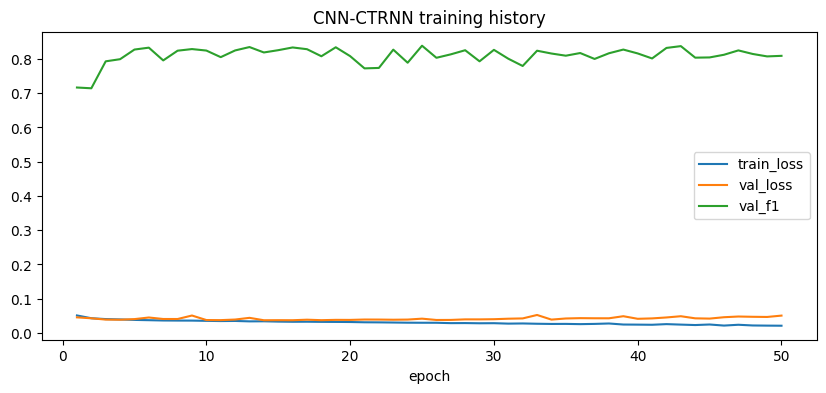

In [ ]:
ctrnn_model = CNN_CTRNN(n_classes=1).to(DEVICE)
optimizer_ctrnn = torch.optim.Adam(ctrnn_model.parameters(), lr=1e-3, weight_decay=1e-4)

ctrnn_model, ctrnn_history = train_model(
    model=ctrnn_model,
    train_loader=train_loader_cnn,
    val_loader=val_loader_cnn,
    criterion=criterion_ct,
    optimizer=optimizer_ctrnn,
    device=DEVICE,
    epochs=50,
    checkpoint_path=CHECKPOINT_ROOT / 'cnn_ctrnn_ptbxl_to_ptbdb.pt',
)

ctrnn_cutoff, ctrnn_val_metrics = find_best_subject_cutoff(ctrnn_model, val_loader_cnn, criterion_ct, DEVICE)
ctrnn_test_metrics = evaluate_subjects(ctrnn_model, test_loader_cnn, criterion_ct, DEVICE, cutoff=ctrnn_cutoff)

print_subject_metrics('CNN-CTRNN validation subjects', ctrnn_val_metrics)
print_subject_metrics('CNN-CTRNN PTBDB test subjects', ctrnn_test_metrics)

ctrnn_history_df = pd.DataFrame(ctrnn_history)
ctrnn_history_df.tail()

plt.figure(figsize=(10, 4))
plt.plot(ctrnn_history_df['epoch'], ctrnn_history_df['train_loss'], label='train_loss')
plt.plot(ctrnn_history_df['epoch'], ctrnn_history_df['val_loss'], label='val_loss')
plt.plot(ctrnn_history_df['epoch'], ctrnn_history_df['val_f1'], label='val_f1')
plt.title('CNN-CTRNN training history')
plt.xlabel('epoch')
plt.legend()
plt.show()

Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50 | train_loss=0.0527 | val_loss=0.0465 | val_acc=0.7349 | val_f1=0.6488 | val_sens=0.3143 | val_spec=0.9944 | val_auc=0.8694
Epoch 2/50 | train_loss=0.0439 | val_loss=0.0410 | val_acc=0.7902 | val_f1=0.7441 | val_sens=0.4792 | val_spec=0.9821 | val_auc=0.8956
Epoch 3/50 | train_loss=0.0411 | val_loss=0.0426 | val_acc=0.8261 | val_f1=0.7981 | val_sens=0.5942 | val_spec=0.9693 | val_auc=0.8945
Epoch 4/50 | train_loss=0.0398 | val_loss=0.0378 | val_acc=0.8275 | val_f1=0.7974 | val_sens=0.5788 | val_spec=0.9810 | val_auc=0.9057
Epoch 5/50 | train_loss=0.0384 | val_loss=0.0421 | val_acc=0.8576 | val_f1=0.8419 | val_sens=0.7111 | val_spec=0.9480 | val_auc=0.9030
Epoch 6/50 | train_loss=0.0379 | val_loss=0.0388 | val_acc=0.8510 | val_f1=0.8332 | val_sens=0.6866 | val_spec=0.9525 | val_auc=0.9075
Epoch 7/50 | train_loss=0.0377 | val_loss=0.0376 | val_acc=0.8324 | val_f1=0.8062 | val_sens=0.6096 | val_spec=0.9698 | val_auc=0.9039
Epoch 8/50 | train_loss=0.0362 | val_loss=0.0436 | val_

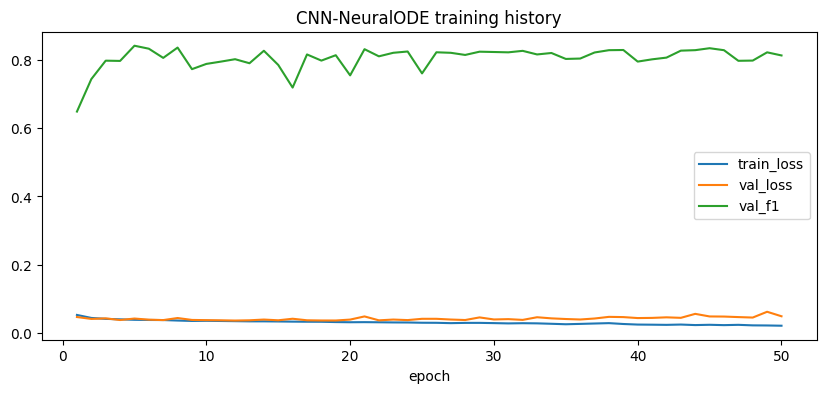

In [ ]:
node_model = CNN_NeuralODE(n_classes=1).to(DEVICE)
optimizer_node = torch.optim.Adam(node_model.parameters(), lr=1e-3, weight_decay=1e-4)

node_model, node_history = train_model(
    model=node_model,
    train_loader=train_loader_cnn,
    val_loader=val_loader_cnn,
    criterion=criterion_ct,
    optimizer=optimizer_node,
    device=DEVICE,
    epochs=50,
    checkpoint_path=CHECKPOINT_ROOT / 'cnn_node_ptbxl_to_ptbdb.pt',
)

node_cutoff, node_val_metrics = find_best_subject_cutoff(node_model, val_loader_cnn, criterion_ct, DEVICE)
node_test_metrics = evaluate_subjects(node_model, test_loader_cnn, criterion_ct, DEVICE, cutoff=node_cutoff)

print_subject_metrics('CNN-NeuralODE validation subjects', node_val_metrics)
print_subject_metrics('CNN-NeuralODE PTBDB test subjects', node_test_metrics)
node_history_df = pd.DataFrame(node_history)
node_history_df.tail()
plt.figure(figsize=(10, 4))
plt.plot(node_history_df['epoch'], node_history_df['train_loss'], label='train_loss')
plt.plot(node_history_df['epoch'], node_history_df['val_loss'], label='val_loss')
plt.plot(node_history_df['epoch'], node_history_df['val_f1'], label='val_f1')
plt.title('CNN-NeuralODE training history')
plt.xlabel('epoch')
plt.legend()
plt.show()

Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50 | train_loss=0.0627 | val_loss=0.0489 | val_acc=0.7380 | val_f1=0.6632 | val_sens=0.3496 | val_spec=0.9776 | val_auc=0.8455
Epoch 2/50 | train_loss=0.0492 | val_loss=0.0442 | val_acc=0.7843 | val_f1=0.7372 | val_sens=0.4728 | val_spec=0.9765 | val_auc=0.8729
Epoch 3/50 | train_loss=0.0444 | val_loss=0.0429 | val_acc=0.8044 | val_f1=0.7652 | val_sens=0.5190 | val_spec=0.9804 | val_auc=0.8852
Epoch 4/50 | train_loss=0.0415 | val_loss=0.0411 | val_acc=0.7864 | val_f1=0.7353 | val_sens=0.4547 | val_spec=0.9911 | val_auc=0.8974
Epoch 5/50 | train_loss=0.0402 | val_loss=0.0426 | val_acc=0.8486 | val_f1=0.8294 | val_sens=0.6721 | val_spec=0.9575 | val_auc=0.8956
Epoch 6/50 | train_loss=0.0383 | val_loss=0.0384 | val_acc=0.8203 | val_f1=0.7881 | val_sens=0.5643 | val_spec=0.9782 | val_auc=0.9027
Epoch 7/50 | train_loss=0.0377 | val_loss=0.0409 | val_acc=0.7957 | val_f1=0.7513 | val_sens=0.4891 | val_spec=0.9849 | val_auc=0.8982
Epoch 8/50 | train_loss=0.0369 | val_loss=0.0389 | val_

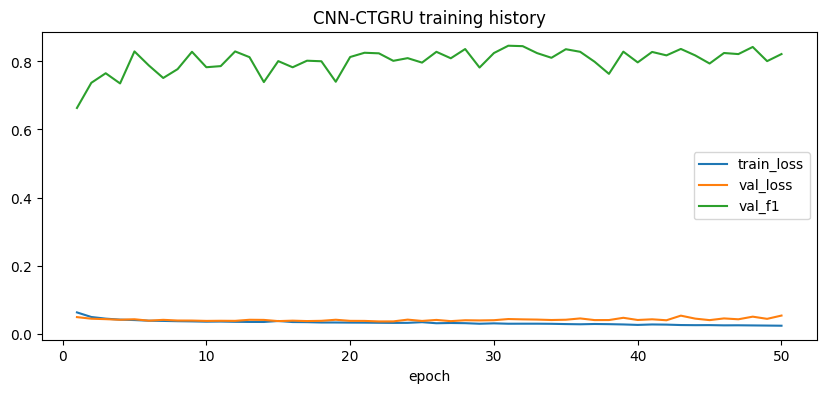

In [ ]:
ctgru_model = CNN_CTGRU(n_classes=1).to(DEVICE)
optimizer_ctgru = torch.optim.Adam(ctgru_model.parameters(), lr=1e-3, weight_decay=1e-4)

ctgru_model, ctgru_history = train_model(
    model=ctgru_model,
    train_loader=train_loader_cnn,
    val_loader=val_loader_cnn,
    criterion=criterion_ct,
    optimizer=optimizer_ctgru,
    device=DEVICE,
    epochs=50,
    checkpoint_path=CHECKPOINT_ROOT / 'cnn_ctgru_ptbxl_to_ptbdb.pt',
)

ctgru_cutoff, ctgru_val_metrics = find_best_subject_cutoff(ctgru_model, val_loader_cnn, criterion_ct, DEVICE)
ctgru_test_metrics = evaluate_subjects(ctgru_model, test_loader_cnn, criterion_ct, DEVICE, cutoff=ctgru_cutoff)

print_subject_metrics('CNN-CTGRU validation subjects', ctgru_val_metrics)
print_subject_metrics('CNN-CTGRU PTBDB test subjects', ctgru_test_metrics)

ctgru_history_df = pd.DataFrame(ctgru_history)
ctgru_history_df.tail()

plt.figure(figsize=(10, 4))
plt.plot(ctgru_history_df['epoch'], ctgru_history_df['train_loss'], label='train_loss')
plt.plot(ctgru_history_df['epoch'], ctgru_history_df['val_loss'], label='val_loss')
plt.plot(ctgru_history_df['epoch'], ctgru_history_df['val_f1'], label='val_f1')
plt.title('CNN-CTGRU training history')
plt.xlabel('epoch')
plt.legend()
plt.show()

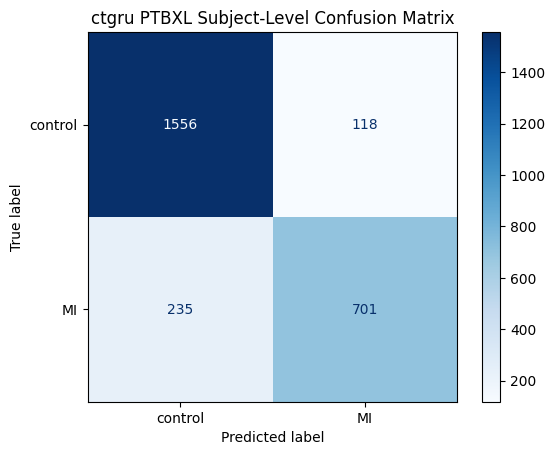

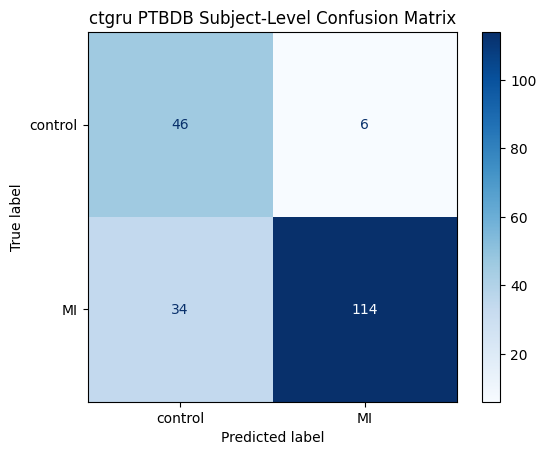

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = ctgru_val_metrics["confusion_matrix"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["control", "MI"])
disp.plot(cmap="Blues", values_format="d")
plt.title("ctgru PTBXL Subject-Level Confusion Matrix")
plt.show()

cm = ctgru_test_metrics["confusion_matrix"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["control", "MI"])
disp.plot(cmap="Blues", values_format="d")
plt.title("ctgru PTBDB Subject-Level Confusion Matrix")
plt.show()

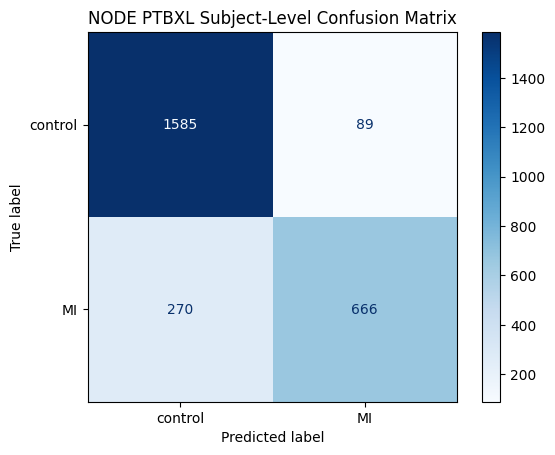

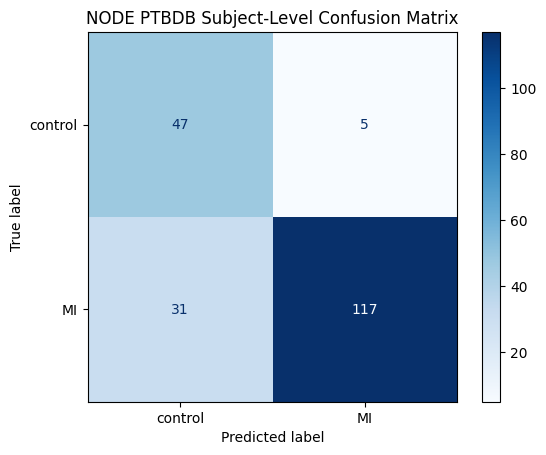

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = node_val_metrics["confusion_matrix"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["control", "MI"])
disp.plot(cmap="Blues", values_format="d")
plt.title("NODE PTBXL Subject-Level Confusion Matrix")
plt.show()

cm = node_test_metrics["confusion_matrix"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["control", "MI"])
disp.plot(cmap="Blues", values_format="d")
plt.title("NODE PTBDB Subject-Level Confusion Matrix")
plt.show()

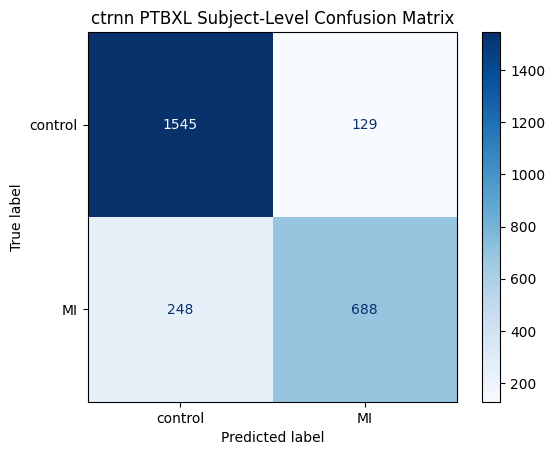

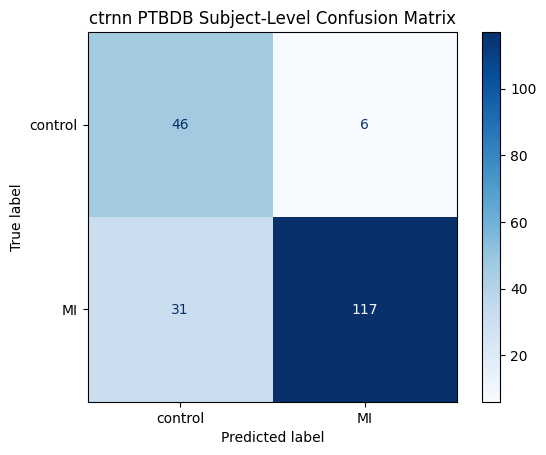

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = ctrnn_val_metrics["confusion_matrix"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["control", "MI"])
disp.plot(cmap="Blues", values_format="d")
plt.title("ctrnn PTBXL Subject-Level Confusion Matrix")
plt.show()

cm = ctrnn_test_metrics["confusion_matrix"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["control", "MI"])
disp.plot(cmap="Blues", values_format="d")
plt.title("ctrnn PTBDB Subject-Level Confusion Matrix")
plt.show()

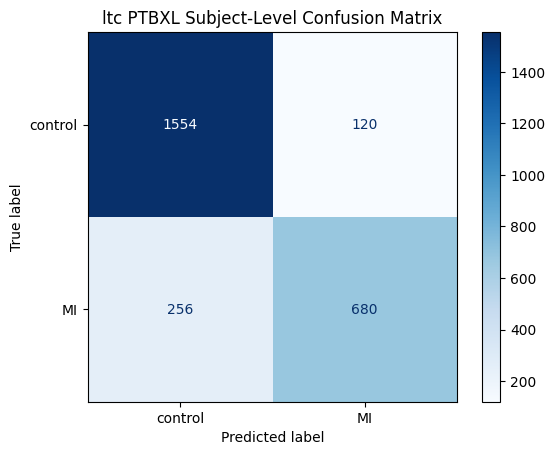

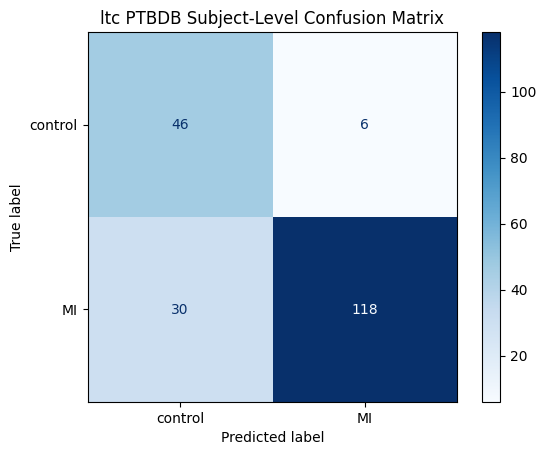

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = ltc_val_metrics["confusion_matrix"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["control", "MI"])
disp.plot(cmap="Blues", values_format="d")
plt.title("ltc PTBXL Subject-Level Confusion Matrix")
plt.show()

cm = ltc_test_metrics["confusion_matrix"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["control", "MI"])
disp.plot(cmap="Blues", values_format="d")
plt.title("ltc PTBDB Subject-Level Confusion Matrix")
plt.show()